# 02 — Exploratory Data Analysis: Phase A — Data Integrity and Split Validation

This notebook documents **Phase A** of the EDA for the MIT-BIH ECG heartbeat dataset, building on the initial data loading and visual inspection performed in `01_data_loading.ipynb` (which is not modified here).

**Phase A objective:** before any preprocessing or modeling decision is made, verify that the dataset itself — its train/test split, its uniqueness, and its value ranges — is trustworthy.

Each analysis below follows the same structure:

> **Scientific question → Analysis → Result → Interpretation → Downstream implication**

**Scope of this notebook:**
- A1 — Train/Test Class Distribution and Split Structure
- A2 — Duplicate and Leakage Screening
- A3 — Value Range and Data Integrity

**Explicitly out of scope for this notebook** (deferred to the next EDA phase): zero-padding / effective signal length analysis, any preprocessing, and any machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.width", 120)

train_df = pd.read_csv("../data/raw/mitbih_train.csv", header=None)
test_df = pd.read_csv("../data/raw/mitbih_test.csv", header=None)

label_col = train_df.shape[1] - 1
feature_cols = list(range(label_col))

class_labels = {
    0.0: "Normal",
    1.0: "Supraventricular ectopic beat",
    2.0: "Ventricular ectopic beat",
    3.0: "Fusion beat",
    4.0: "Unknown beat",
}

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")

Train shape: (87554, 188)
Test shape:  (21892, 188)


## Phase A1 — Train/Test Class Distribution and Split Structure

**Objective:** Determine whether the provided train/test split preserves the class distribution of the full dataset, and whether row ordering within each file could bias any future sampling or cross-validation scheme.

**Scientific question:** Is the train/test split stratified by class, and is the row order inside each CSV randomized or structured?

**Why this matters:** If class proportions differ substantially between train and test, evaluation metrics computed on the test set may not reflect the model's behavior on the training distribution. If rows are ordered rather than shuffled, any code that samples positionally (e.g. `df.head(1000)`) or any cross-validation method that does not explicitly shuffle (e.g. scikit-learn's `KFold` with default settings) will produce biased or degenerate folds.

In [2]:
train_counts = train_df[label_col].value_counts().sort_index()
test_counts = test_df[label_col].value_counts().sort_index()

train_pct = (train_counts / train_counts.sum() * 100).round(3)
test_pct = (test_counts / test_counts.sum() * 100).round(3)

split_summary = pd.DataFrame({
    "class": [class_labels[c] for c in train_counts.index],
    "train_count": train_counts.values,
    "train_pct": train_pct.values,
    "test_count": test_counts.reindex(train_counts.index).values,
    "test_pct": test_pct.reindex(train_counts.index).values,
})
split_summary["pct_diff (train-test)"] = (split_summary["train_pct"] - split_summary["test_pct"]).round(3)
split_summary["train_ratio (train/(train+test))"] = (
    train_counts.values / (train_counts.values + test_counts.reindex(train_counts.index).values)
).round(4)

display(split_summary)

,class,train_count,train_pct,test_count,test_pct,pct_diff (train-test),train_ratio (train/(train+test))
0,Normal,72471,82.773,18118,82.761,0.012,0.8000
1,Supraventricular ectopic beat,2223,2.539,556,2.540,-0.001,0.7999
2,Ventricular ectopic beat,5788,6.611,1448,6.614,-0.003,0.7999
3,Fusion beat,641,0.732,162,0.740,-0.008,0.7983
4,Unknown beat,6431,7.345,1608,7.345,0.000,0.8000


**Result:** Every class is split at almost exactly 80% train / 20% test — the per-class ratio ranges from about 0.798 to 0.800, and the largest train/test percentage-point gap for any class is under 0.02. Normal beats make up ~82.8% of both train and test; the rarest class, Fusion, makes up ~0.73–0.74% of both.

**Interpretation:** The tightness of this match, for a highly imbalanced dataset, is far beyond what a random split of this size would typically produce by chance. This is consistent with the split having been constructed with **explicit stratification by class**.

**Limitation:** This is an inference about the *proportions*, not about *which* records ended up in which set. A stratified proportion match says nothing about whether the underlying patients or recordings are independent between train and test — that question requires patient/record identifiers, which do not exist in these CSV files. **This result does not prove patient-level independence between train and test.**

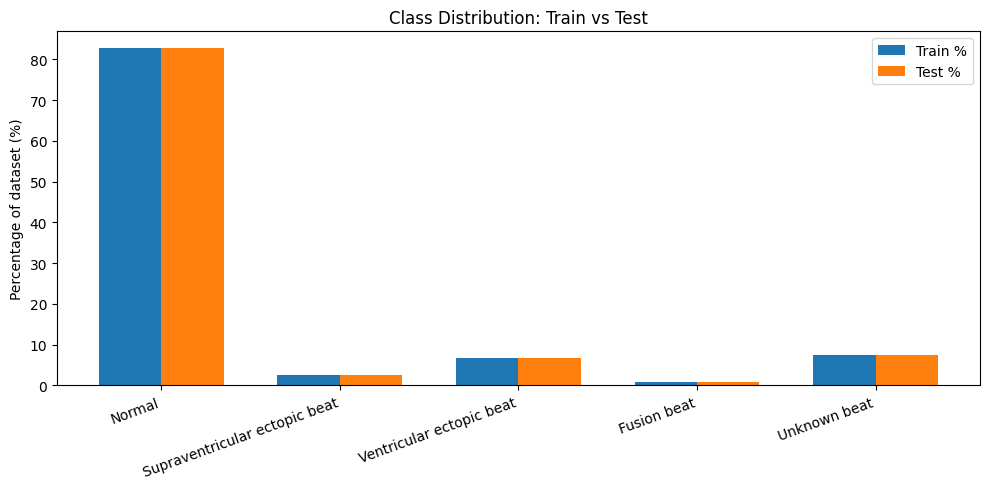

In [3]:
x = np.arange(len(split_summary))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, split_summary["train_pct"], width, label="Train %")
ax.bar(x + width/2, split_summary["test_pct"], width, label="Test %")

ax.set_xticks(x)
ax.set_xticklabels(split_summary["class"], rotation=20, ha="right")
ax.set_ylabel("Percentage of dataset (%)")
ax.set_title("Class Distribution: Train vs Test")
ax.legend()
plt.tight_layout()
plt.show()

**Result:** The chart shows the train and test bars for each class visually overlapping almost perfectly, consistent with the numeric comparison above.

**Interpretation:** This is a visual confirmation, not new evidence — it makes the near-identical per-class proportions easy to communicate, but doesn't change the limitation noted above.

In [4]:
def ordering_report(df, name):
    labels = df[label_col].values
    n = len(labels)
    change_points = np.sum(labels[1:] != labels[:-1])
    n_runs = change_points + 1
    same_next_frac = 1 - (change_points / (n - 1))

    print(f"--- {name} (n={n}) ---")
    print(f"Contiguous runs of identical label: {n_runs} "
          f"(min possible = {df[label_col].nunique()}, max possible = {n})")
    print(f"Fraction of adjacent rows sharing the same label: {same_next_frac:.5f}")

    rows = []
    for c in sorted(df[label_col].unique()):
        idx = np.where(labels == c)[0]
        span = idx.max() - idx.min() + 1
        rows.append({
            "class": class_labels[c], "first_idx": idx.min(), "last_idx": idx.max(),
            "span": span, "count": len(idx), "span/count": round(span / len(idx), 3),
        })
    display(pd.DataFrame(rows))

ordering_report(train_df, "TRAIN")
ordering_report(test_df, "TEST")

--- TRAIN (n=87554) ---
Contiguous runs of identical label: 5 (min possible = 5, max possible = 87554)
Fraction of adjacent rows sharing the same label: 0.99995


,class,first_idx,last_idx,span,count,span/count
0,Normal,0,72470,72471,72471,1.0
1,Supraventricular ectopic beat,72471,74693,2223,2223,1.0
2,Ventricular ectopic beat,74694,80481,5788,5788,1.0
3,Fusion beat,80482,81122,641,641,1.0
4,Unknown beat,81123,87553,6431,6431,1.0


--- TEST (n=21892) ---
Contiguous runs of identical label: 5 (min possible = 5, max possible = 21892)
Fraction of adjacent rows sharing the same label: 0.99982


,class,first_idx,last_idx,span,count,span/count
0,Normal,0,18117,18118,18118,1.0
1,Supraventricular ectopic beat,18118,18673,556,556,1.0
2,Ventricular ectopic beat,18674,20121,1448,1448,1.0
3,Fusion beat,20122,20283,162,162,1.0
4,Unknown beat,20284,21891,1608,1608,1.0


**Result:** In both train and test, the label column shows only 5 contiguous runs — one per class — with over 99.9% of adjacent rows sharing the same label. Per class, `span / count = 1.000` in every case, meaning each class occupies one unbroken block of rows (e.g. in `mitbih_train.csv`, rows 0–72470 are entirely class 0, followed immediately by class 1, and so on).

**Interpretation:** Neither CSV is shuffled — the rows are grouped by class label in file order. This is an observed structural fact, not an assumption.

**Why this matters for future work:**
- **Positional sampling is unsafe.** Any subset taken by row position (e.g. "first N rows for a quick test") would return an almost entirely single-class sample.
- **Unshuffled cross-validation would be invalid.** Scikit-learn's `KFold` defaults to `shuffle=False`; applied directly to these files, each fold would be built from a near-mono-class contiguous block, producing degenerate, uninformative validation folds.
- **Recommendation for later phases:** any splitting or cross-validation performed on this data must either shuffle explicitly (with a fixed random seed for reproducibility) or use a stratified method (e.g. `StratifiedKFold`), given the class imbalance already confirmed here.

## Phase A2 — Duplicate and Leakage Screening

**Objective:** Check whether identical heartbeat samples appear more than once — within a single file, or across the train/test boundary.

**Scientific question:** Does the dataset contain exact duplicate rows, and if so, could any of them cross the train/test split in a way that would leak test information into training?

**Why this matters:** If the same beat appears in both train and test, a model could achieve artificially high test performance simply by memorizing that specific row, rather than by learning generalizable ECG morphology.

In [5]:
train_dup_within = train_df.duplicated(keep=False).sum()
test_dup_within = test_df.duplicated(keep=False).sum()

print(f"Exact duplicate rows within TRAIN: {train_dup_within} ({train_dup_within/len(train_df)*100:.2f}%)")
print(f"Exact duplicate rows within TEST:  {test_dup_within} ({test_dup_within/len(test_df)*100:.2f}%)")

# Cross-set check: hash pre-filter, then verify with an actual row-equality merge
# (hash collisions alone would not be reliable proof of an exact duplicate)
train_hashes = pd.util.hash_pandas_object(train_df, index=False)
test_hashes = pd.util.hash_pandas_object(test_df, index=False)
hash_overlap = test_hashes.isin(set(train_hashes.values))
n_hash_overlap = hash_overlap.sum()

if n_hash_overlap > 0:
    confirmed = test_df[hash_overlap.values].merge(train_df, how="inner")
    n_confirmed = len(confirmed)
else:
    n_confirmed = 0

print(f"TEST rows exactly matching a TRAIN row (hash pre-filter): {n_hash_overlap}")
print(f"Confirmed exact-row duplicates between TRAIN and TEST (verified): {n_confirmed} "
      f"({n_confirmed/len(test_df)*100:.2f}% of test set)")

Exact duplicate rows within TRAIN: 0 (0.00%)
Exact duplicate rows within TEST:  0 (0.00%)
TEST rows exactly matching a TRAIN row (hash pre-filter): 0
Confirmed exact-row duplicates between TRAIN and TEST (verified): 0 (0.00% of test set)


**Result:** No exact duplicate rows were found within train, within test, or across train and test (verified by full-row equality after a hash-based pre-filter, not hash comparison alone — hash collisions were checked against the actual row values).

**Interpretation:** There is no evidence of exact-copy leakage between train and test in these files.

**Why a near-duplicate (similarity-based) analysis is not implemented here:** Detecting *near*-duplicates (e.g. two highly similar but not identical beats) would require choosing a similarity metric and a threshold to decide what counts as "the same underlying beat." Any such threshold would be arbitrary without external ground truth (e.g. knowing which beats come from the same patient recording) to calibrate it — so it was intentionally left out rather than implemented on an unjustified cutoff.

**Limitation — this is important:** These CSV files contain **no patient or recording identifier**. The original MIT-BIH database consists of a limited number of long recordings from a limited number of patients, and consecutive beats from the same patient are known to be highly similar to each other. Because of this:
- The absence of exact duplicates **does not prove** the split is free of leakage.
- Near-duplicate, same-patient beats could still be split across train and test without being caught by exact matching.
- Patient-level independence between train and test **cannot be verified from these CSV files alone.**

## Phase A3 — Value Range and Data Integrity

**Objective:** Confirm that the dataset is numerically clean and that its values fall within the range implied by the documented preprocessing (per-beat min-max normalization) before any further work is done.

**Scientific question:** Are there missing, infinite, non-numeric, or out-of-range values in either file, and are the two files schema-compatible?

**Why this matters:** Any preprocessing or modeling decision made on top of unverified data risks building on a false assumption (e.g. assuming no missing values, or assuming a [0,1] range for a scaler) that later causes silent errors.

In [6]:
print("Missing values")
for name, df in [("TRAIN", train_df), ("TEST", test_df)]:
    print(f"  {name}: total NaN cells = {df.isna().sum().sum()}")

print("\nInfinite values")
for name, df in [("TRAIN", train_df), ("TEST", test_df)]:
    print(f"  {name}: infinite cells = {np.isinf(df.values).sum()}")

print("\nDtypes / non-numeric columns")
for name, df in [("TRAIN", train_df), ("TEST", test_df)]:
    non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()
    print(f"  {name}: unique dtypes = {list(df.dtypes.unique())}, non-numeric columns = {non_numeric}")

print("\nSchema compatibility")
print(f"  Train shape: {train_df.shape}   Test shape: {test_df.shape}")
print(f"  Same number of columns: {train_df.shape[1] == test_df.shape[1]}")
print(f"  Columns with dtype mismatch: {(train_df.dtypes.values != test_df.dtypes.values).sum()}")

Missing values
  TRAIN: total NaN cells = 0
  TEST: total NaN cells = 0

Infinite values


  TRAIN: infinite cells = 0
  TEST: infinite cells = 0

Dtypes / non-numeric columns
  TRAIN: unique dtypes = [dtype('float64')], non-numeric columns = []
  TEST: unique dtypes = [dtype('float64')], non-numeric columns = []

Schema compatibility
  Train shape: (87554, 188)   Test shape: (21892, 188)
  Same number of columns: True
  Columns with dtype mismatch: 0


In [7]:
print("ECG feature value range (columns 0-186, label excluded)")
for name, df in [("TRAIN", train_df), ("TEST", test_df)]:
    feat = df[feature_cols]
    below0 = (feat < 0).values.sum()
    above1 = (feat > 1).values.sum()
    print(f"  {name}: min={feat.values.min():.6f}, max={feat.values.max():.6f}, "
          f"values<0: {below0}, values>1: {above1}")

print("\nLabel column integrity (column 187)")
expected_labels = set(class_labels.keys())
for name, df in [("TRAIN", train_df), ("TEST", test_df)]:
    observed = set(df[label_col].unique())
    unexpected = observed - expected_labels
    print(f"  {name}: observed labels = {sorted(observed)}, unexpected labels = {sorted(unexpected)}")

ECG feature value range (columns 0-186, label excluded)


  TRAIN: min=0.000000, max=1.000000, values<0: 0, values>1: 0
  TEST: min=0.000000, max=1.000000, values<0: 0, values>1: 0

Label column integrity (column 187)
  TRAIN: observed labels = [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)], unexpected labels = []
  TEST: observed labels = [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)], unexpected labels = []


In [8]:
print("Flatline / zero-variance rows (feature columns only)")
for name, df in [("TRAIN", train_df), ("TEST", test_df)]:
    feat = df[feature_cols]
    all_zero = (feat == 0).all(axis=1).sum()
    zero_variance = (feat.std(axis=1) == 0).sum()
    print(f"  {name}: all-zero rows = {all_zero}, zero-variance rows = {zero_variance}")

Flatline / zero-variance rows (feature columns only)


  TRAIN: all-zero rows = 0, zero-variance rows = 0
  TEST: all-zero rows = 0, zero-variance rows = 0


**Results:**
- No missing values, no infinite values, and no non-numeric columns in either file — both are pure `float64` across all 188 columns.
- Train and test have identical shape structure (188 columns each) and identical dtypes column-for-column.
- All 187 ECG feature values fall within [0, 1] in both files, with zero values below 0 or above 1.
- Both files contain only the five expected label values {0, 1, 2, 3, 4} — no unexpected classes.
- No flatline (all-zero) or zero-variance rows in either file.

**Interpretation:** On every check performed here, the dataset is internally consistent and clean. The [0,1] range is consistent with per-beat min-max normalization having already been applied by whoever produced these CSV files.

**Limitation — scope of this conclusion:** These checks confirm that the data is *internally* clean and within an expected numeric range; they do **not** by themselves establish that no further normalization or scaling will ever be needed later in the pipeline. That depends on decisions not yet made (e.g. how features are engineered, which model family is chosen, whether the two datasets are combined with others such as PTBDB). This section states only what current evidence supports — the absence of a *currently visible* integrity problem — not a guarantee about future preprocessing requirements.

## Phase A — Summary

**Facts established directly from the data:**
- The train/test split preserves per-class proportions to within ~0.02 percentage points for every class.
- Both CSV files are ordered (block-sorted) by class label, not shuffled.
- No exact duplicate rows exist within or across train/test.
- No missing, infinite, non-numeric, or out-of-range values exist in either file; schemas match.

**Interpretations built on those facts:**
- The split was very likely constructed with explicit stratification by class.
- Any future sampling, splitting, or cross-validation on this data must shuffle explicitly and account for class imbalance.

**Documented limitations (explicitly not resolved by this notebook):**
- Patient/record-level independence between train and test cannot be verified — no patient identifiers exist in these files, and exact-duplicate absence does not rule out near-duplicate, same-patient leakage.
- Data integrity checks confirm the *current* state is clean; they do not guarantee no normalization will be needed once feature engineering or model-specific preprocessing begins.

**Next steps (deferred to a later notebook/phase):**
- Zero-padding and effective signal length analysis.
- Any preprocessing or model training — intentionally not started here.

## Phase B — Effective Signal Length and Zero-Padding

**Objective:** Characterize the trailing zero-padding present in the fixed-length (187-sample) beat representation, and determine whether the amount of padding is associated with heartbeat class.

**Verified provenance (source paper — Kachuee, Fazeli & Sarrafzadeh, *ECG Heartbeat Classification: A Deep Transferable Representation*, arXiv:1805.00794; see also the provenance addendum in `docs/Engineering_Journal.md`):**
- The original MIT-BIH recordings were sampled at **360 Hz**.
- The pipeline used to derive these CSV files **resamples the signal to 125 Hz** before segmenting it into individual beats.
- Beats are **explicitly zero-padded to a fixed length (187 samples)** as an intentional design choice of the pipeline, so that every row has the same width regardless of the beat's actual duration — it is not an artifact of missing data.

**Scientific question:** Is the amount of trailing zero-padding associated with heartbeat class, and if so, is that association better explained by the data-generation/extraction procedure than by an intrinsic physiological property of the beat?

**Scope of this section:** This is diagnostic EDA only. No preprocessing decision (e.g. masking, cropping, or using length as a feature) is made here, and no model is trained. Phase A (data integrity and split validation, above) is unmodified.


### B1 — Trailing Zero-Padding and the Effective-Length Proxy

**Objective:** Define and compute, for every beat, the number of trailing zero samples and a corresponding "effective length" proxy (the number of leading samples up to and including the last non-zero value).

**Scientific question:** Given the fixed 187-sample window, how much of it is actually trailing padding on a typical beat?


In [9]:
from scipy import stats

def trailing_zero_count(feat_matrix):
    '''Number of trailing zero columns per row, counted from the end of the window.'''
    reversed_nonzero = feat_matrix[:, ::-1] != 0
    n_features = feat_matrix.shape[1]
    col_idx = np.arange(n_features)
    first_nonzero_from_end = np.where(reversed_nonzero, col_idx, n_features).min(axis=1)
    return first_nonzero_from_end

def effective_length(feat_matrix):
    '''Proxy for pre-padding beat length: 1 + index of the last non-zero sample per row.'''
    return feat_matrix.shape[1] - trailing_zero_count(feat_matrix)

train_feat = train_df[feature_cols].values
test_feat = test_df[feature_cols].values
n_features = train_feat.shape[1]

train_len = pd.DataFrame({
    "label": train_df[label_col].values,
    "class": [class_labels[c] for c in train_df[label_col].values],
    "trailing_zeros": trailing_zero_count(train_feat),
    "effective_length": effective_length(train_feat),
})
test_len = pd.DataFrame({
    "label": test_df[label_col].values,
    "class": [class_labels[c] for c in test_df[label_col].values],
    "trailing_zeros": trailing_zero_count(test_feat),
    "effective_length": effective_length(test_feat),
})

print(f"Fixed window length: {n_features} samples")
print(f"TRAIN effective_length range: [{train_len['effective_length'].min()}, {train_len['effective_length'].max()}]")
print(f"TEST  effective_length range: [{test_len['effective_length'].min()}, {test_len['effective_length'].max()}]")


Fixed window length: 187 samples
TRAIN effective_length range: [17, 187]
TEST  effective_length range: [10, 187]


**Result:** `effective_length` and `trailing_zeros` were computed directly from the raw feature columns for every row in both files (no assumptions, no hard-coded lengths) and always sum to the fixed window size of 187.

**Interpretation:** `effective_length` is a **proxy**, not a verified physiological boundary — a beat whose true signal happens to cross exactly zero at its last recorded sample would be indistinguishable, by this definition, from a beat that ends there due to padding. It is used consistently across the whole analysis below with that caveat in mind.


### B2 — Distribution of Effective Length (Train vs. Test)

**Objective:** Summarize the overall distribution of `effective_length` in each split and check whether train and test are consistent with each other.

**Scientific question:** Is trailing padding the exception or the norm across the dataset, and does its distribution differ between train and test?


In [10]:
def describe_length(df, name):
    summary = df["effective_length"].describe(percentiles=[.25, .5, .75]).to_frame(name=name)
    full_window_pct = (df["effective_length"] == n_features).mean() * 100
    return summary, full_window_pct

train_summary, train_full_pct = describe_length(train_len, "TRAIN")
test_summary, test_full_pct = describe_length(test_len, "TEST")

length_overview = train_summary.join(test_summary)
display(length_overview.round(2))

print(f"\nBeats using the full {n_features}-sample window (no padding at all):")
print(f"  TRAIN: {train_full_pct:.2f}%")
print(f"  TEST:  {test_full_pct:.2f}%")


,TRAIN,TEST
count,87554.00,21892.00
mean,111.69,111.42
std,27.46,27.44
min,17.00,10.00
25%,94.00,94.00
50%,109.00,108.00
75%,127.00,127.00
max,187.00,187.00



Beats using the full 187-sample window (no padding at all):
  TRAIN: 0.90%
  TEST:  0.86%


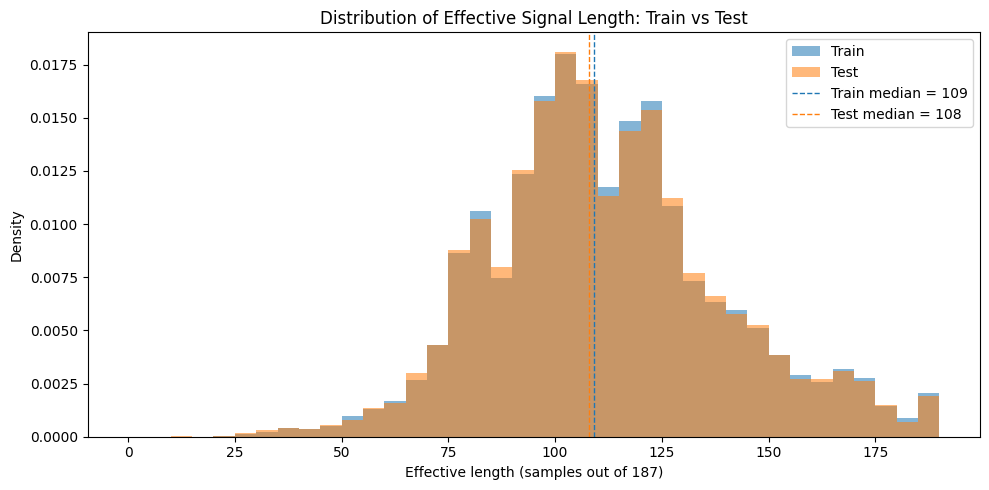

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
bins = np.arange(0, n_features + 5, 5)
ax.hist(train_len["effective_length"], bins=bins, density=True, alpha=0.55, label="Train")
ax.hist(test_len["effective_length"], bins=bins, density=True, alpha=0.55, label="Test")
ax.axvline(train_len["effective_length"].median(), color="C0", linestyle="--", linewidth=1,
           label=f"Train median = {train_len['effective_length'].median():.0f}")
ax.axvline(test_len["effective_length"].median(), color="C1", linestyle="--", linewidth=1,
           label=f"Test median = {test_len['effective_length'].median():.0f}")
ax.set_xlabel("Effective length (samples out of 187)")
ax.set_ylabel("Density")
ax.set_title("Distribution of Effective Signal Length: Train vs Test")
ax.legend()
plt.tight_layout()
plt.show()


**Result:** Trailing padding is the norm, not the exception — well under 1% of beats in either split use the full 187-sample window, and the two splits show closely matching medians, means, and shape (visually near-overlapping histograms, both right-skewed with a long tail toward the full window length).

**Interpretation:** The overall padding pattern is stable between train and test, so any downstream effect tied to `effective_length` (e.g. the class association tested in B4–B5) is not an artifact of how the train/test split happened to fall.


### B3 — Per-Class Effective-Length Statistics

**Objective:** Break the same distribution down by heartbeat class, in both splits, to see whether any class stands out.

**Scientific question:** Does the amount of trailing padding differ systematically by class, and is any such difference consistent between train and test?


In [12]:
def per_class_stats(df, name):
    stats_df = df.groupby("class")["effective_length"].agg(["count", "mean", "median", "std", "min", "max"])
    stats_df = stats_df.reindex(class_labels.values()).round(2)
    return stats_df

def per_class_full_window_rate(df):
    return (df.groupby("class")["effective_length"]
              .apply(lambda s: (s == n_features).mean() * 100)
              .reindex(class_labels.values())
              .round(2))

train_class_stats = per_class_stats(train_len, "TRAIN")
test_class_stats = per_class_stats(test_len, "TEST")

print("--- TRAIN: per-class effective_length ---")
display(train_class_stats)
print("--- TEST: per-class effective_length ---")
display(test_class_stats)

class_comparison = train_class_stats[["mean", "median", "std"]].join(
    test_class_stats[["mean", "median", "std"]], lsuffix="_train", rsuffix="_test"
)
print("--- TRAIN vs TEST: per-class mean/median/std ---")
display(class_comparison)

full_window_rate = pd.DataFrame({
    "train_full_window_pct": per_class_full_window_rate(train_len),
    "test_full_window_pct": per_class_full_window_rate(test_len),
})
print("--- Per-class rate of using the FULL window (no padding) ---")
display(full_window_rate)


--- TRAIN: per-class effective_length ---


,count,mean,median,std,min,max
class,,,,,,
Normal,72471,110.81,106.0,27.18,17,187
Supraventricular ectopic beat,2223,113.91,107.0,39.24,22,187
Ventricular ectopic beat,5788,118.17,114.0,34.91,27,187
Fusion beat,641,78.83,78.0,13.92,29,187
Unknown beat,6431,118.28,120.0,9.74,31,183


--- TEST: per-class effective_length ---


,count,mean,median,std,min,max
class,,,,,,
Normal,18118,110.55,106.0,27.14,10,187
Supraventricular ectopic beat,556,115.19,108.0,38.34,24,187
Ventricular ectopic beat,1448,116.80,112.0,35.51,14,187
Fusion beat,162,76.99,78.0,13.07,30,160
Unknown beat,1608,118.55,120.0,8.94,39,141


--- TRAIN vs TEST: per-class mean/median/std ---


,mean_train,median_train,std_train,mean_test,median_test,std_test
class,,,,,,
Normal,110.81,106.0,27.18,110.55,106.0,27.14
Supraventricular ectopic beat,113.91,107.0,39.24,115.19,108.0,38.34
Ventricular ectopic beat,118.17,114.0,34.91,116.80,112.0,35.51
Fusion beat,78.83,78.0,13.92,76.99,78.0,13.07
Unknown beat,118.28,120.0,9.74,118.55,120.0,8.94


--- Per-class rate of using the FULL window (no padding) ---


,train_full_window_pct,test_full_window_pct
class,,
Normal,0.43,0.46
Supraventricular ectopic beat,11.92,10.79
Ventricular ectopic beat,3.58,3.11
Fusion beat,0.16,0.00
Unknown beat,0.00,0.00


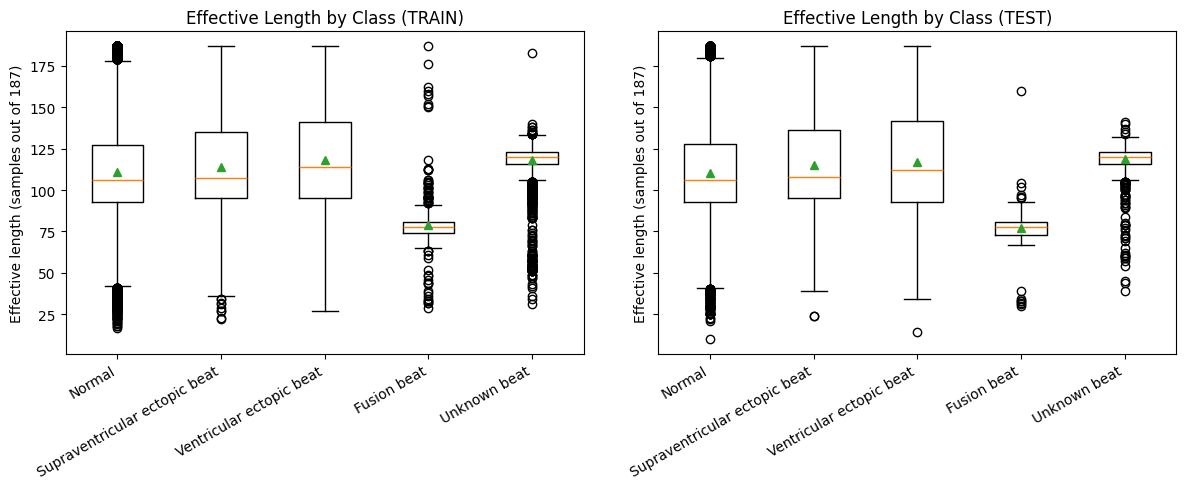

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, df, name in zip(axes, [train_len, test_len], ["TRAIN", "TEST"]):
    data = [df.loc[df["class"] == c, "effective_length"].values for c in class_labels.values()]
    ax.boxplot(data, tick_labels=list(class_labels.values()), showmeans=True)
    ax.set_title(f"Effective Length by Class ({name})")
    ax.set_ylabel("Effective length (samples out of 187)")
    ax.tick_params(axis="x", rotation=30)
    for label in ax.get_xticklabels():
        label.set_ha("right")
plt.tight_layout()
plt.show()


**Result:**
- **Fusion beats are a clear structural outlier** in both splits: much shorter median effective length than every other class, and a much tighter spread (lower standard deviation) than every other class.
- The other four classes overlap substantially with each other, though Normal, Supraventricular, and Ventricular beats show wide spreads (large standard deviations) while Unknown beats are tightly clustered.
- **Supraventricular ectopic beats show a distinct secondary signature:** a full-window (no-padding) rate roughly three times higher than any other class in both splits, while every other class rarely reaches the full window.
- Per-class patterns are consistent between train and test — the same class ordering and the same outliers (Fusion, Supraventricular) appear in both.

**Interpretation:** Two different signals are visible here — a large, class-specific outlier (Fusion, driven by its short and tightly-distributed effective length) and a separate, narrower signal (Supraventricular's elevated full-window rate). Both are examined statistically below.


### B4 — Kruskal-Wallis Association Test and Effect Size

**Objective:** Test, formally, whether `effective_length` differs across classes overall, and quantify how much of the variance in ranks is explained by class membership.

**Why Kruskal-Wallis instead of ANOVA:** The per-class distributions above are visibly skewed with unequal variances across classes, violating ANOVA's normality/homoscedasticity assumptions. Kruskal-Wallis is a non-parametric, rank-based alternative that does not require them.


In [14]:
def kruskal_wallis_report(df, name):
    groups = [g["effective_length"].values for _, g in df.groupby("class")]
    h_stat, p_value = stats.kruskal(*groups)
    n = len(df)
    k = df["class"].nunique()
    epsilon_sq = (h_stat - k + 1) / (n - k)  # epsilon-squared effect size for Kruskal-Wallis
    print(f"--- {name} ---")
    print(f"  H statistic = {h_stat:.2f}, df = {k - 1}, p-value = {p_value:.3e}")
    print(f"  epsilon-squared (effect size) = {epsilon_sq:.4f}")
    return h_stat, p_value, epsilon_sq

train_kw = kruskal_wallis_report(train_len, "TRAIN")
test_kw = kruskal_wallis_report(test_len, "TEST")


--- TRAIN ---
  H statistic = 2790.52, df = 4, p-value = 0.000e+00
  epsilon-squared (effect size) = 0.0318
--- TEST ---
  H statistic = 716.56, df = 4, p-value = 9.054e-154
  epsilon-squared (effect size) = 0.0326


**Result:** In both splits, the Kruskal-Wallis test finds a statistically significant association between class and effective length (p ≈ 0), but the epsilon-squared effect size is small (a few percent) — class membership explains only a small share of the overall rank variance in effective length, and this is consistent between train and test.

**Interpretation:** A small *global* effect size does not contradict the large, clearly visible Fusion outlier from B3 — it means the other four classes overlap enough with each other that the omnibus (all-classes-at-once) test is diluted by that overlap, even though one specific class (Fusion) drives a strong, isolated signal. This is why a targeted, class-specific test is needed next.


### B5 — Fusion vs. Rest: Targeted Comparison

**Objective:** Test the outlier flagged descriptively in B3 directly — Fusion beats vs. all other classes pooled — using a two-group non-parametric test and an effect size appropriate for it.

**Why Mann-Whitney U / rank-biserial:** Mann-Whitney U is the two-group counterpart to Kruskal-Wallis and shares its non-parametric, rank-based assumptions. Rank-biserial correlation converts the U statistic into an effect size on a [-1, 1] scale and has a direct probabilistic interpretation (probability of superiority).


In [15]:
def fusion_vs_rest_report(df, name):
    fusion = df.loc[df["class"] == "Fusion beat", "effective_length"].values
    rest = df.loc[df["class"] != "Fusion beat", "effective_length"].values
    u_stat, p_value = stats.mannwhitneyu(fusion, rest, alternative="two-sided")
    n1, n2 = len(fusion), len(rest)
    rank_biserial = 1 - (2 * u_stat) / (n1 * n2)
    prob_fusion_shorter = 1 - (u_stat / (n1 * n2))  # P(a random Fusion beat < a random non-Fusion beat)
    print(f"--- {name}: Fusion (n={n1}) vs Rest (n={n2}) ---")
    print(f"  U statistic = {u_stat:.1f}, p-value = {p_value:.3e}")
    print(f"  rank-biserial correlation = {rank_biserial:.3f}")
    print(f"  P(random Fusion beat is shorter than random non-Fusion beat) = {prob_fusion_shorter * 100:.1f}%")
    return u_stat, p_value, rank_biserial, prob_fusion_shorter

train_fusion = fusion_vs_rest_report(train_len, "TRAIN")
test_fusion = fusion_vs_rest_report(test_len, "TEST")


--- TRAIN: Fusion (n=641) vs Rest (n=86913) ---
  U statistic = 6377812.5, p-value = 8.066e-249
  rank-biserial correlation = 0.771
  P(random Fusion beat is shorter than random non-Fusion beat) = 88.6%
--- TEST: Fusion (n=162) vs Rest (n=21730) ---
  U statistic = 365403.5, p-value = 7.565e-68
  rank-biserial correlation = 0.792
  P(random Fusion beat is shorter than random non-Fusion beat) = 89.6%


**Result:** Fusion vs. the rest of the dataset is a large, highly significant effect in both splits (p ≈ 0, rank-biserial correlation in the 0.7–0.8 range) — a randomly chosen Fusion beat is shorter than a randomly chosen non-Fusion beat roughly 85–90% of the time, consistently in train and test.

**Interpretation:** This confirms, formally, what B3's descriptive statistics suggested: Fusion is not just nominally different in effective length — it is a large, reproducible, class-specific effect that a length-sensitive model could exploit as a shortcut, separately from the smaller global association found in B4.


## Phase B — Summary

**Facts established directly from the data:**
- Trailing zero-padding is present in the large majority of beats in both splits; using the full 187-sample window with no padding is rare (well under 1% of beats).
- Fusion beats have a substantially shorter median effective length and a much tighter spread than every other class, reproducibly in both train and test.
- Supraventricular ectopic beats use the full window at a distinctly higher rate than every other class, reproducibly in both train and test.
- Kruskal-Wallis confirms a statistically significant but small global association between class and effective length (epsilon-squared: a few percent) in both splits.
- A targeted Fusion-vs-rest comparison confirms a large, statistically significant effect (rank-biserial in the 0.7–0.8 range) in both splits.

**Interpretations built on those facts, held cautiously:**
- `effective_length` is a **proxy** derived from trailing zeros, not a verified physiological signal boundary — a beat whose genuine value happens to be exactly 0.0 at its last recorded sample is indistinguishable from padding under this definition.
- Zero-padding is confirmed (per the verified provenance above) to be an **intentional feature of this derived dataset's representation** — a fixed-width encoding choice made by the source pipeline — not evidence of missing or corrupted data.
- The 360 Hz → 125 Hz resampling and the beat-extraction step both happen *before* this padding is applied, so segment length reflects **the source pipeline's extraction/resampling procedure**, not a property directly measured from the original analog signal.
- Given the above, the Fusion-length association found here should be treated as a **data-generation-procedure signature correlated with class**, not as evidence that Fusion beats are intrinsically shorter in physiological duration. This notebook does not have the information needed (the extraction algorithm's exact rule for choosing segment boundaries) to distinguish those two explanations conclusively.

**Shortcut-learning risk:** Because effective length separates Fusion from the rest of the dataset well above chance, any model architecture sensitive to padding (directly, e.g. an explicit length feature, or indirectly, e.g. sequence-length-sensitive layers) has a route to detect Fusion beats without learning ECG morphology. Fusion is simultaneously the rarest class and the one most reachable by this shortcut, so a future model's Fusion recall should not be attributed to morphology learning without first checking a trivial length-based baseline.

**Documented limitations (explicitly not resolved by this notebook):**
- The exact rule used by the source pipeline to choose each beat's pre-padding boundary is not verified here; only the *presence and pattern* of the resulting padding is characterized.
- Statistical association does not establish a causal or physiological mechanism.
- `effective_length` is a structural proxy computed from zero values, not a ground-truth beat-duration label.

**Next steps (deferred to a later notebook/phase):**
- Any preprocessing decision about padding (masking, cropping, using length as an explicit feature, or leaving it as-is) is deferred to the preprocessing phase, informed by the evidence above — no such decision is made here.
- Any Fusion-class performance claim in later modeling phases must be checked against a length-only baseline before being attributed to learned morphology.
- No classifier is trained and no preprocessing is performed in this notebook.
